# Learning patient-specific clonal patterns from SCEPTR embeddings

Assumes **`reps`** (`calc_vector_representations`, `(27159, 64)`) and **`mdata`** (`obs['patient']`, `obs['cloned']`).

**Three phases — only the first is already done:**

| Phase | Supervision | Where |
|---|---|---|
| SCEPTR pre-training (autocontrastive + MLM) | unsupervised | baked into `reps` |
| Supervised adaptation to `cloned`, all patients | supervised | Stage 1 |
| Per-patient specialisation | supervised | Stage 2 |

Stages 1 & 2 train a projection head on **frozen** `reps`; SCEPTR's weights are untouched.

**Leakage / overfit safeguards:**
- **Three-way split** (train / val / test), stratified by patient × cloned. Test cells gate everything and are only ever scored, never fit.
- **Early stopping on validation loss** in both stages (matches the paper's fine-tuning protocol) — so `n_epochs` is never tuned against the test set.
- Per-patient models **deepcopy** the global head, so Stage 2 never modifies the shared global model.
- Evaluation: nearest cloned-reference distance — references = train cells, queries = test cells.

In [1]:
import numpy as np
import pandas as pd
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42); np.random.seed(42)
device

'cuda'

## SCEPTR

In [2]:
from pandas import DataFrame
import sceptr
import pandas as pd
import muon as mu

In [3]:
path = r"/ix1/ylee/Yifan_Zhang/Code_data/Tumor/GSE139555_2019/data/Processed/"
filename = "T_DE_per_sample_TCRembvdjdb_singlets.h5mu"
DATA_PATH = path + filename

mdata_ori = mu.read(DATA_PATH)

In [4]:
mdata = mdata_ori.copy()
mdata

MuData object with n_obs × n_vars = 27159 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length', 'vdjdb_match', 'vdjdb_label'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	27159 × 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'X_umap_harmony', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors', 'neighbors_harmony', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	27159 × 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [5]:
clone_df = mdata.obs[["unique_clone_id", "vdjdb_match",
                      "VJ_1_cdr3_aa","VJ_1_v_call","VJ_1_j_call",
            "VDJ_1_cdr3_aa","VDJ_1_v_call","VDJ_1_j_call"]]

# Create a dictionary mapping the old names to the new names
rename_mapping = {
    "VJ_1_cdr3_aa": "cdr3_a_aa",
    "VJ_1_v_call": "v_a_gene",
    "VJ_1_j_call": "j_a_gene",
    "VDJ_1_cdr3_aa": "cdr3_b_aa",
    "VDJ_1_v_call": "v_b_gene",
    "VDJ_1_j_call": "j_b_gene"
}

# Rename the columns
clone_df = clone_df.rename(columns=rename_mapping)
print(clone_df.head())               

                       unique_clone_id  vdjdb_match     cdr3_a_aa  v_a_gene  \
LT1_CACATAGAGTGTACCT-1         Lung1_0        False  ALGSQGGSEKLV   TRAV9-2   
LN3_CTTAGGATCGCGCCAA-2     Lung3_10014        False    ALWLYGNKLV    TRAV16   
LN1_CCTATTAAGTCTCAAC-1      Lung1_1003         True    AMRYTGNQFY  TRAV12-3   
LN3_GTAACTGAGTTAGGTA-2     Lung3_10035         True   AVNNNAGNMLT   TRAV8-1   
LN3_GACGCGTTCAGTGTTG-2     Lung3_10046        False  AVCSGGSNYKLT    TRAV21   

                       j_a_gene       cdr3_b_aa  v_b_gene j_b_gene  
LT1_CACATAGAGTGTACCT-1   TRAJ57  ASSQDQTARSYGYT   TRBV4-1  TRBJ1-2  
LN3_CTTAGGATCGCGCCAA-2   TRAJ47  ASRWGKGARTGELF    TRBV19  TRBJ2-2  
LN1_CCTATTAAGTCTCAAC-1   TRAJ49  ASSSRLAGFTGELF   TRBV5-4  TRBJ2-2  
LN3_GTAACTGAGTTAGGTA-2   TRAJ39   ASSLGGYSNQPQH   TRBV7-9  TRBJ1-5  
LN3_GACGCGTTCAGTGTTG-2   TRAJ53  SAPDRGVPSNYGYT  TRBV20-1  TRBJ1-2  


In [6]:
match_df = clone_df[clone_df["vdjdb_match"] == True]
unmatch_df = clone_df[clone_df["vdjdb_match"] == False]

In [7]:
import logging
import pandas as pd
import tidytcells as tt

logging.basicConfig(level=logging.WARNING)

# ---- 2. Map AIRR/scirpy columns -> TRAV/CDR3A/TRBV/CDR3B (+ J genes) ------
def prefix_c(s):
    """Prepend 'C' to CDR3 aa seqs; leave empty/NaN as ''."""
    s = s.astype(str)
    return ("C" + s + "F").where(s.notna() & (s != "") & (s != "nan"), "")

In [8]:
tcr_all = pd.DataFrame({
    "TRAV":  clone_df["v_a_gene"].values,   # keep raw IMGT symbol (e.g. TRAV1-2*01)
    "TRAJ":  clone_df["j_a_gene"].values,
    "CDR3A": prefix_c(clone_df["cdr3_a_aa"]).values,
    "TRBV":  clone_df["v_b_gene"].values,
    "TRBJ":  clone_df["j_b_gene"].values,
    "CDR3B": prefix_c(clone_df["cdr3_b_aa"]).values,
},  index=clone_df.index)

# ---- 3. Standardize V/J genes to IMGT gene-level -------------------------
# NOTE 1: set species correctly. "homosapiens" / "musmusculus" / "any".
SPECIES = "homosapiens"
cols = ["TRAV", "TRAJ", "TRBV", "TRBJ"]
tcr_all[cols] = tcr_all[cols].map(
    lambda x: tt.tr.standardize(
        symbol=x,
        species=SPECIES,
        precision="gene",
        enforce_functional=True,   # drop ORF/pseudogenes like TRBV21-1
        on_fail="reject",          # return None on failure
        log_failures=True,
    ),
    na_action="ignore",
)

print(tcr_all.head())

                            TRAV    TRAJ           CDR3A      TRBV     TRBJ  \
LT1_CACATAGAGTGTACCT-1   TRAV9-2  TRAJ57  CALGSQGGSEKLVF   TRBV4-1  TRBJ1-2   
LN3_CTTAGGATCGCGCCAA-2    TRAV16  TRAJ47    CALWLYGNKLVF    TRBV19  TRBJ2-2   
LN1_CCTATTAAGTCTCAAC-1  TRAV12-3  TRAJ49    CAMRYTGNQFYF   TRBV5-4  TRBJ2-2   
LN3_GTAACTGAGTTAGGTA-2   TRAV8-1  TRAJ39   CAVNNNAGNMLTF   TRBV7-9  TRBJ1-5   
LN3_GACGCGTTCAGTGTTG-2    TRAV21  TRAJ53  CAVCSGGSNYKLTF  TRBV20-1  TRBJ1-2   

                                   CDR3B  
LT1_CACATAGAGTGTACCT-1  CASSQDQTARSYGYTF  
LN3_CTTAGGATCGCGCCAA-2  CASRWGKGARTGELFF  
LN1_CCTATTAAGTCTCAAC-1  CASSSRLAGFTGELFF  
LN3_GTAACTGAGTTAGGTA-2   CASSLGGYSNQPQHF  
LN3_GACGCGTTCAGTGTTG-2  CSAPDRGVPSNYGYTF  


In [9]:
reps = sceptr.calc_vector_representations(tcr_all)
reps.shape

(27159, 64)

## 1. Three-way split: train / val / test (stratified by patient × cloned)

`test` gates all training and is only scored. `val` is used purely for early stopping, so epoch counts are never chosen by looking at `test`.

In [10]:
le      = LabelEncoder()
y_all   = le.fit_transform(mdata.obs['cloned'].values.astype(str))
patient = mdata.obs['patient'].values
CLONED  = list(le.classes_).index('True') if 'True' in le.classes_ else 1
print(f'class map {dict(enumerate(le.classes_))}  (positive = {CLONED})')

strat = np.array([f'{p}|{c}' for p, c in zip(patient, y_all)])
idx   = np.arange(len(y_all))
vc    = pd.Series(strat).value_counts()

def safe_split(ix, frac, seed):
    s = strat[ix]
    ok = np.isin(s, vc[vc >= 2].index)
    a, b = train_test_split(ix[ok], test_size=frac, stratify=s[ok], random_state=seed)
    return np.concatenate([a, ix[~ok]]), b   # singletons -> first bucket

trainval_idx, test_idx = safe_split(idx, 0.20, 42)              # 80 / 20
train_idx,    val_idx  = safe_split(trainval_idx, 0.20, 43)     # 64 / 16 of total

is_train = np.zeros(len(y_all), bool); is_train[train_idx] = True
is_val   = np.zeros(len(y_all), bool); is_val[val_idx]     = True
is_test  = np.zeros(len(y_all), bool); is_test[test_idx]   = True
print(f'train {is_train.sum()}   val {is_val.sum()}   test {is_test.sum()}')

class map {0: np.str_('False'), 1: np.str_('True')}  (positive = 1)
train 17381   val 4346   test 5432


## 2. Architecture, loss, training (with early stopping)

In [11]:
class ProjectionHead(nn.Module):
    def __init__(self, d_in=64, d_hidden=128, d_out=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hidden), nn.BatchNorm1d(d_hidden), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(d_hidden, d_out))
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__(); self.t = temperature
    def forward(self, z, y):
        N = z.shape[0]; sim = (z @ z.T) / self.t
        yc = y.unsqueeze(1)
        pos = (yc == yc.T).float(); pos.fill_diagonal_(0.)
        den = torch.ones(N, N, device=z.device); den.fill_diagonal_(0.)
        sim = sim - sim.max(1, keepdim=True).values.detach()
        logp = sim - torch.log((torch.exp(sim) * den).sum(1, keepdim=True) + 1e-9)
        npos = pos.sum(1); loss = -(pos * logp).sum(1) / (npos + 1e-9)
        v = npos > 0
        return loss[v].mean() if v.any() else torch.tensor(0., requires_grad=True, device=z.device)

In [12]:
def fit_supcon(model, X, y, n_epochs, batch_size, lr,
               X_val=None, y_val=None, patience=6,
               temperature=0.07, balance=True, verbose=False):
    """Supervised-contrastive fine-tune. Early stops on val SupCon loss if val given."""
    Xt = torch.tensor(X, dtype=torch.float32).to(device)
    yt = torch.tensor(y, dtype=torch.long).to(device)
    opt  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = SupConLoss(temperature)

    use_val = (X_val is not None) and (len(np.unique(y_val)) >= 2)
    if use_val:
        Xv = torch.tensor(X_val, dtype=torch.float32).to(device)
        yv = torch.tensor(y_val, dtype=torch.long).to(device)

    bs = min(batch_size, len(X))
    if balance:
        w = (1.0 / np.bincount(y))[y]
        sampler = WeightedRandomSampler(torch.tensor(w, dtype=torch.double), len(y), replacement=True)
        loader  = DataLoader(TensorDataset(Xt, yt), batch_size=bs, sampler=sampler, drop_last=True)
    else:
        loader  = DataLoader(TensorDataset(Xt, yt), batch_size=bs, shuffle=True, drop_last=True)

    best, best_state, wait = np.inf, None, 0
    tr_hist, val_hist = [], []
    for ep in range(n_epochs):
        model.train(); el = []
        for xb, yb in loader:
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); el.append(loss.item())
        tr_hist.append(np.mean(el) if el else np.nan)
        if use_val:
            model.eval()
            with torch.no_grad():
                vl = crit(model(Xv), yv).item()
            val_hist.append(vl)
            if vl < best - 1e-4:
                best, best_state, wait = vl, copy.deepcopy(model.state_dict()), 0
            else:
                wait += 1
                if wait >= patience:
                    if verbose: print(f'    early stop @ {ep+1}  (best val {best:.4f})')
                    break
    if use_val and best_state is not None:
        model.load_state_dict(best_state)
    return tr_hist, val_hist

@torch.no_grad()
def transform(model, X, bs=512):
    model.eval()
    return np.vstack([model(torch.tensor(X[i:i+bs], dtype=torch.float32).to(device)).cpu().numpy()
                      for i in range(0, len(X), bs)])

## 3. Stage 1 — global fine-tune (train split, early stop on val)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
auc = cross_val_score(clf, reps, y_all, cv=5, scoring='roc_auc')
print(f'linear probe AUROC on raw reps: {auc.mean():.3f} ± {auc.std():.3f}')

linear probe AUROC on raw reps: 0.518 ± 0.011


In [ ]:
# ***************
# This mean there is nothing to learn
# ********************

Stage 1 — global fine-tune
    early stop @ 17  (best val 8.3771)


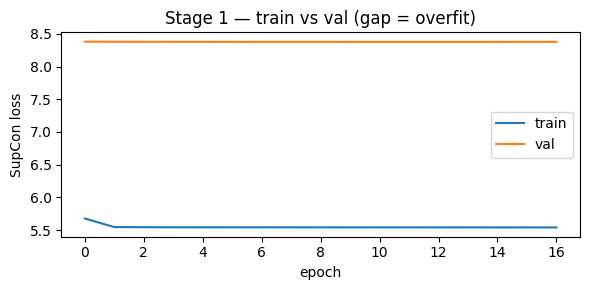

In [13]:
global_model = ProjectionHead().to(device)
print('Stage 1 — global fine-tune')
tr_h, val_h = fit_supcon(
    global_model, reps[is_train], y_all[is_train],
    n_epochs=100, batch_size=256, lr=1e-3,
    X_val=reps[is_val], y_val=y_all[is_val],
    patience=8, verbose=True)

plt.figure(figsize=(6, 3))
plt.plot(tr_h, label='train'); plt.plot(val_h, label='val')
plt.xlabel('epoch'); plt.ylabel('SupCon loss'); plt.legend()
plt.title('Stage 1 — train vs val (gap = overfit)'); plt.tight_layout(); plt.show()
emb_global = transform(global_model, reps)

## 4. Nearest cloned-reference AUROC (paper-style, held-out test)

In [14]:
def nn_auroc(emb, ref_mask, query_mask, y, patient, min_ref=5, min_q=5):
    rows = []
    for p in np.unique(patient):
        pm = patient == p
        ref_cloned = pm & ref_mask & (y == CLONED)
        q = pm & query_mask
        if ref_cloned.sum() < min_ref or q.sum() < min_q or len(np.unique(y[q])) < 2:
            continue
        d = cdist(emb[q], emb[ref_cloned]).min(1)
        rows.append((p, q.sum(), roc_auc_score((y[q] == CLONED).astype(int), -d)))
    return pd.DataFrame(rows, columns=['patient', 'n_test', 'auroc'])

# references = train cells; queries = held-out test cells
z = nn_auroc(reps,       is_train, is_test, y_all, patient).rename(columns={'auroc': 'zeroshot'})
g = nn_auroc(emb_global, is_train, is_test, y_all, patient).rename(columns={'auroc': 'global'})
print(f'patients evaluated: {len(z)}')

patients evaluated: 14


## 5. Stage 2 — per-patient (warm start, early stop on patient val)

Each patient deepcopies the global head, then fine-tunes on its own **train** cells with early stopping on its own **val** cells (falls back to a few fixed epochs when val is too small).

In [15]:
pp = []
for i, p in enumerate(np.unique(patient)):
    pm = patient == p
    tr, va, te = pm & is_train, pm & is_val, pm & is_test
    ytr = y_all[tr]
    if len(np.unique(ytr)) < 2 or np.bincount(ytr).min() < 5 or te.sum() < 5:
        continue

    pmodel = copy.deepcopy(global_model)
    has_val = va.sum() >= 10 and len(np.unique(y_all[va])) >= 2
    fit_supcon(pmodel, reps[tr], ytr,
               n_epochs=30 if has_val else 6,
               batch_size=min(64, tr.sum()), lr=3e-4,
               X_val=reps[va] if has_val else None,
               y_val=y_all[va] if has_val else None,
               patience=4)

    emb_p = transform(pmodel, reps)
    r = nn_auroc(emb_p, is_train, is_test, y_all, patient)
    r = r[r.patient == p]
    if len(r):
        a = float(r['auroc'].iloc[0]); pp.append((p, a))
        print(f'[{i+1}] {p:18s} val={"y" if has_val else "n"}  per-patient AUROC {a:.3f}')

pp = pd.DataFrame(pp, columns=['patient', 'per_patient'])

[1] Colon1             val=y  per-patient AUROC 0.628
[2] Colon2             val=y  per-patient AUROC 0.097
[3] Endo1              val=y  per-patient AUROC 0.495
[4] Endo2              val=y  per-patient AUROC 0.590
[5] Endo3              val=y  per-patient AUROC 0.481
[6] Lung1              val=y  per-patient AUROC 0.530
[7] Lung2              val=y  per-patient AUROC 0.489
[8] Lung3              val=y  per-patient AUROC 0.526
[9] Lung4              val=y  per-patient AUROC 0.564
[10] Lung5              val=y  per-patient AUROC 0.499
[11] Lung6              val=y  per-patient AUROC 0.548
[12] Renal1             val=y  per-patient AUROC 0.521
[13] Renal2             val=y  per-patient AUROC 0.527
[14] Renal3             val=y  per-patient AUROC 0.539


## 6. Compare the three conditions on the held-out test set

In [16]:
summary = (z.merge(g[['patient', 'global']], on='patient')
             .merge(pp, on='patient', how='left')
             .sort_values('per_patient', ascending=False).reset_index(drop=True))
for c in ['zeroshot', 'global', 'per_patient']:
    print(f'median {c:12s} {summary[c].median():.3f}')
v = summary['per_patient'].notna()
print(f'\nglobal   > zeroshot : {(summary["global"] > summary["zeroshot"]).sum()} / {len(summary)}')
print(f'per-pat. > global   : {(summary.loc[v, "per_patient"] > summary.loc[v, "global"]).sum()} / {v.sum()}')
summary

median zeroshot     0.552
median global       0.522
median per_patient  0.527

global   > zeroshot : 3 / 14
per-pat. > global   : 10 / 14


,patient,n_test,zeroshot,global,per_patient
0,Colon1,265,0.589361,0.619650,0.628391
1,Endo2,159,0.516944,0.582161,0.590473
2,Lung4,249,0.564569,0.526265,0.564159
3,Lung6,919,0.538436,0.528365,0.548254
4,Renal3,151,0.587270,0.555446,0.538714
5,Lung1,531,0.515493,0.522834,0.530310
6,Renal2,474,0.553092,0.520330,0.527099
7,Lung3,638,0.533563,0.529051,0.526098
8,Renal1,144,0.560336,0.491765,0.521345
9,Lung5,382,0.589315,0.513911,0.498589


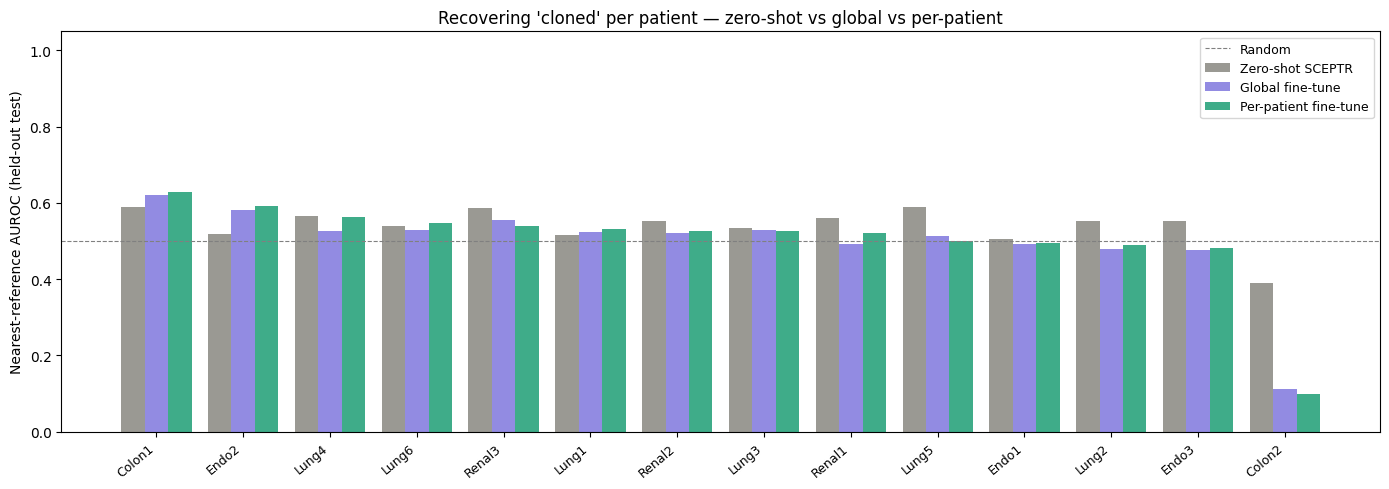

In [17]:
x = np.arange(len(summary)); w = 0.27
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w, summary['zeroshot'],    w, label='Zero-shot SCEPTR',     color='#888780', alpha=.85)
ax.bar(x,     summary['global'],      w, label='Global fine-tune',     color='#7F77DD', alpha=.85)
ax.bar(x + w, summary['per_patient'], w, label='Per-patient fine-tune', color='#1D9E75', alpha=.85)
ax.axhline(0.5, color='grey', ls='--', lw=.8, label='Random')
ax.set_xticks(x); ax.set_xticklabels(summary['patient'], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Nearest-reference AUROC (held-out test)'); ax.set_ylim(0, 1.05)
ax.set_title("Recovering 'cloned' per patient — zero-shot vs global vs per-patient")
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig('patient_specific_results.png', dpi=150, bbox_inches='tight'); plt.show()